# Preprocessing and Augmentation Experiment：

We keep the model fixed (`tds_conv_ctc`) and vary transform settings only.

In [1]:
from pathlib import Path
import os

CANDIDATES = [
    Path('/content/drive/MyDrive/emg2qwerty'),
    Path('/content/emg2qwerty'),
    Path('/Users/byte/Library/CloudStorage/GoogleDrive-zijiezh@g.ucla.edu/My Drive/emg2qwerty'),
]
REPO = next((p for p in CANDIDATES if p.exists()), None)
if REPO is None:
    raise FileNotFoundError('Could not find repo in known locations.')

os.chdir(REPO)
print('Working directory:', Path.cwd())

Working directory: /content/drive/MyDrive/emg2qwerty


In [2]:
import importlib
import sys

required = ['hydra', 'pytorch_lightning', 'torch', 'tensorboard', 'yaml']
missing = [pkg for pkg in required if importlib.util.find_spec(pkg) is None]
print('Python:', sys.executable)
if missing:
    print('Missing packages:', missing)
    print('Install with: pip install -r requirements.txt && pip install -e .')
else:
    print('All required packages found.')

Python: /usr/bin/python3
All required packages found.


In [3]:
import os
import subprocess
import sys
import time
from pathlib import Path
from collections import deque

import yaml


def has_gpu() -> bool:
    try:
        import torch
        return bool(torch.cuda.is_available())
    except Exception:
        return False


def preflight_data_check() -> None:
    cfg_path = REPO / 'config' / 'user' / 'single_user.yaml'
    data_root = REPO / 'data'
    if not cfg_path.exists():
        raise FileNotFoundError(f'Missing user split config: {cfg_path}')
    if not data_root.exists():
        raise FileNotFoundError(f'Missing data directory: {data_root}')

    cfg = yaml.safe_load(cfg_path.read_text())
    missing = []
    for split in ['train', 'val', 'test']:
        for item in cfg['dataset'][split]:
            hdf5_path = data_root / f"{item['session']}.hdf5"
            if not hdf5_path.exists():
                missing.append(hdf5_path)

    if missing:
        preview = '\n'.join(str(p) for p in missing[:10])
        raise FileNotFoundError(
            f'Missing {len(missing)} data files under {data_root}. First 10:\n{preview}'
        )

    print('Preflight data check passed.')


ACCELERATOR = 'gpu' if has_gpu() else 'cpu'
MAX_EPOCHS = 40
AUTO_FALLBACK_TO_CPU = True
BASE_MODEL = 'tds_conv_ctc'

EXPERIMENTS = [
    {
        'name': 'baseline_default_aug',
        'overrides': [],
    },
    {
        'name': 'no_aug',
        'overrides': [
            'band_rotation.transform.offsets=[0]',
            'temporal_jitter.max_offset=0',
            'specaug.n_time_masks=0',
            'specaug.n_freq_masks=0',
        ],
    },
    {
        'name': 'no_band_rotation',
        'overrides': ['band_rotation.transform.offsets=[0]'],
    },
    {
        'name': 'no_temporal_jitter',
        'overrides': ['temporal_jitter.max_offset=0'],
    },
    {
        'name': 'strong_specaug',
        'overrides': [
            'specaug.n_time_masks=5',
            'specaug.time_mask_param=40',
            'specaug.n_freq_masks=3',
            'specaug.freq_mask_param=6',
        ],
    },
    {
        'name': 'faster_hop_8',
        'overrides': ['logspec.hop_length=8'],
    },
]

print('Accelerator:', ACCELERATOR)
print('Max epochs:', MAX_EPOCHS)
print('Experiments:', [e['name'] for e in EXPERIMENTS])
preflight_data_check()


def run_dir_for(exp_name: str, accel: str) -> Path:
    return REPO / 'logs' / 'preprocess_experiment' / 'runs' / f'{exp_name}_{accel}'


def build_args(exp_name: str, accel: str, extra_overrides: list[str]):
    run_dir = run_dir_for(exp_name, accel)
    args = [
        f'model={BASE_MODEL}',
        'user=single_user',
        f'trainer.accelerator={accel}',
        'trainer.devices=1',
        f'trainer.max_epochs={MAX_EPOCHS}',
        '+trainer.enable_progress_bar=true',
        f'hydra.run.dir={run_dir}',
        'num_workers=0',
    ]
    args.extend(extra_overrides)
    return args


def run_with_live_output(cmd, log_file: Path):
    tail = deque(maxlen=120)
    env = os.environ.copy()
    env['HYDRA_FULL_ERROR'] = '1'

    log_file.parent.mkdir(parents=True, exist_ok=True)
    with log_file.open('w', encoding='utf-8') as lf:
        proc = subprocess.Popen(
            cmd,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True,
            bufsize=1,
            env=env,
        )
        assert proc.stdout is not None
        for line in proc.stdout:
            print(line, end='')
            lf.write(line)
            tail.append(line.rstrip('\n'))

        ret = proc.wait()

    if ret != 0:
        print(f'\nFull log saved to: {log_file}')
        print('\n----- Last 120 log lines -----')
        print('\n'.join(tail))
        raise RuntimeError(f'Command failed with exit code {ret}')


def run_experiment(exp: dict, accel: str):
    exp_name = exp['name']
    overrides = exp['overrides']
    run_dir = run_dir_for(exp_name, accel)
    last_ckpt = run_dir / 'checkpoints' / 'last.ckpt'
    if last_ckpt.exists():
        print(f'Resuming from existing checkpoint: {last_ckpt}')

    cmd = [
        sys.executable,
        '-m',
        'emg2qwerty.train',
        *build_args(exp_name, accel, overrides),
    ]

    print('\nRunning:', ' '.join(cmd), flush=True)
    start = time.time()
    log_file = REPO / 'logs' / 'preprocess_experiment' / f'{exp_name}_{accel}.log'
    run_with_live_output(cmd, log_file)
    elapsed_min = (time.time() - start) / 60.0
    print(f"{exp_name} completed successfully on {accel} in {elapsed_min:.1f} min.")


for i, exp in enumerate(EXPERIMENTS, start=1):
    print(f"\n===== Experiment {i}/{len(EXPERIMENTS)}: {exp['name']} =====")
    try:
        run_experiment(exp, ACCELERATOR)
    except Exception as e:
        if ACCELERATOR == 'gpu' and AUTO_FALLBACK_TO_CPU:
            print(f"\nGPU run failed for {exp['name']}: {e}")
            print('Retrying once on CPU...')
            run_experiment(exp, 'cpu')
        else:
            raise

print('\nAll preprocessing/augmentation experiments completed.')

Accelerator: gpu
Max epochs: 40
Experiments: ['baseline_default_aug', 'no_aug', 'no_band_rotation', 'no_temporal_jitter', 'strong_specaug', 'faster_hop_8']
Preflight data check passed.

===== Experiment 1/6: baseline_default_aug =====

Running: /usr/bin/python3 -m emg2qwerty.train model=tds_conv_ctc user=single_user trainer.accelerator=gpu trainer.devices=1 trainer.max_epochs=40 +trainer.enable_progress_bar=true hydra.run.dir=/content/drive/MyDrive/emg2qwerty/logs/preprocess_experiment/runs/baseline_default_aug_gpu num_workers=0
[2026-03-06 07:03:40,157][__main__][INFO] - 
Config:
user: single_user
dataset:
  train:
  - user: 89335547
    session: 2021-06-03-1622765527-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622681518-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-04-1622863166-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 20

In [4]:
from pathlib import Path
import pandas as pd
from tensorboard.backend.event_processing import event_accumulator


def latest_scalar(event_file: Path, tag: str):
    ea = event_accumulator.EventAccumulator(str(event_file))
    ea.Reload()
    if tag not in ea.Tags().get('scalars', []):
        return None
    events = ea.Scalars(tag)
    return events[-1].value if events else None


def read_exp_name(run_dir: Path) -> str:
    hydra_cfg = run_dir / 'hydra_configs' / 'overrides.yaml'
    if hydra_cfg.exists():
        for line in hydra_cfg.read_text().splitlines():
            if line.startswith('hydra.run.dir='):
                suffix = Path(line.split('=', 1)[1]).name
                if suffix.endswith('_gpu'):
                    return suffix[:-4]
                if suffix.endswith('_cpu'):
                    return suffix[:-4]
                return suffix

    name = run_dir.name
    if name.endswith('_gpu'):
        return name[:-4]
    if name.endswith('_cpu'):
        return name[:-4]
    return name


runs_root = REPO / 'logs' / 'preprocess_experiment' / 'runs'
run_dirs = sorted([p for p in runs_root.glob('*') if p.is_dir()])
print(f'Found {len(run_dirs)} run dirs under {runs_root}')

rows = []
for run_dir in run_dirs:
    event_files = sorted(
        run_dir.glob('lightning_logs/**/events.out.tfevents.*'),
        key=lambda p: p.stat().st_mtime,
    )
    if not event_files:
        continue

    latest_event = event_files[-1]
    rows.append(
        {
            'experiment': read_exp_name(run_dir),
            'run_dir': str(run_dir),
            'event_file': str(latest_event),
            'val_CER': latest_scalar(latest_event, 'val/CER'),
            'test_CER': latest_scalar(latest_event, 'test/CER'),
            'val_loss': latest_scalar(latest_event, 'val/loss'),
            'test_loss': latest_scalar(latest_event, 'test/loss'),
        }
    )

results_df = pd.DataFrame(rows)
if not results_df.empty:
    results_df['status'] = results_df['test_CER'].apply(
        lambda x: 'complete' if pd.notna(x) else 'in_progress'
    )
    results_df = results_df.sort_values('test_CER', na_position='last').reset_index(drop=True)

results_df

Found 6 run dirs under /content/drive/MyDrive/emg2qwerty/logs/preprocess_experiment/runs


,experiment,run_dir,event_file,val_CER,test_CER,val_loss,test_loss,status
0,no_band_rotation,/content/drive/MyDrive/emg2qwerty/logs/preproc...,/content/drive/MyDrive/emg2qwerty/logs/preproc...,None,23.211584,None,0.732969,complete
1,no_temporal_jitter,/content/drive/MyDrive/emg2qwerty/logs/preproc...,/content/drive/MyDrive/emg2qwerty/logs/preproc...,None,25.221525,None,0.818402,complete
2,baseline_default_aug,/content/drive/MyDrive/emg2qwerty/logs/preproc...,/content/drive/MyDrive/emg2qwerty/logs/preproc...,None,25.480873,None,0.812173,complete
3,strong_specaug,/content/drive/MyDrive/emg2qwerty/logs/preproc...,/content/drive/MyDrive/emg2qwerty/logs/preproc...,None,27.404366,None,0.847163,complete
4,no_aug,/content/drive/MyDrive/emg2qwerty/logs/preproc...,/content/drive/MyDrive/emg2qwerty/logs/preproc...,None,29.630430,None,1.036083,complete
5,faster_hop_8,/content/drive/MyDrive/emg2qwerty/logs/preproc...,/content/drive/MyDrive/emg2qwerty/logs/preproc...,None,62.264965,None,1.386601,complete


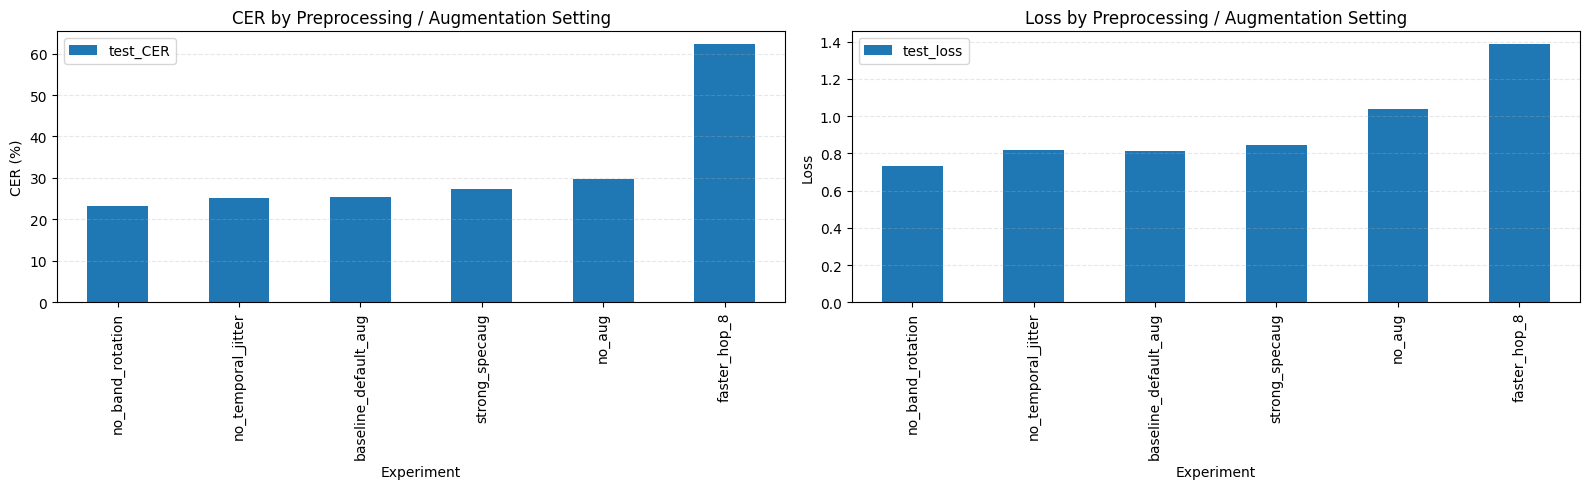

,experiment,status,val_CER,test_CER,val_loss,test_loss
0,no_band_rotation,complete,None,23.211584,None,0.732969
1,no_temporal_jitter,complete,None,25.221525,None,0.818402
2,baseline_default_aug,complete,None,25.480873,None,0.812173
3,strong_specaug,complete,None,27.404366,None,0.847163
4,no_aug,complete,None,29.630430,None,1.036083
5,faster_hop_8,complete,None,62.264965,None,1.386601


In [5]:
import matplotlib.pyplot as plt

if results_df.empty:
    print('No results to plot yet. Run training and metrics extraction first.')
else:
    plot_df = results_df.copy().sort_values('test_CER', na_position='last')

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    cer_cols = ['val_CER', 'test_CER']
    plot_df.set_index('experiment')[cer_cols].plot(kind='bar', ax=axes[0])
    axes[0].set_title('CER by Preprocessing / Augmentation Setting')
    axes[0].set_ylabel('CER (%)')
    axes[0].set_xlabel('Experiment')
    axes[0].grid(axis='y', linestyle='--', alpha=0.3)

    loss_cols = ['val_loss', 'test_loss']
    plot_df.set_index('experiment')[loss_cols].plot(kind='bar', ax=axes[1])
    axes[1].set_title('Loss by Preprocessing / Augmentation Setting')
    axes[1].set_ylabel('Loss')
    axes[1].set_xlabel('Experiment')
    axes[1].grid(axis='y', linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.show()

    display(plot_df[['experiment', 'status', 'val_CER', 'test_CER', 'val_loss', 'test_loss']])

In [6]:
out_csv = REPO / 'preprocessing_metrics_summary.csv'
results_df.to_csv(out_csv, index=False)
print('Saved:', out_csv)

Saved: /content/drive/MyDrive/emg2qwerty/preprocessing_metrics_summary.csv
